# 05j — E3d EfficientNet-B4 Cross-Dataset Evaluation on Celeb-DF v2

**Experiment:** E3d — EfficientNet-B4/380 trained with the verified official-SBI pipeline  
**External dataset:** Fixed Celeb-DF v2 pilot: 20 real videos + 20 fake videos, 10 frames per video

This notebook evaluates the saved E3d checkpoint on genuine Celeb-DF face crops. It performs no training, adaptation, SBI generation, checkpoint selection or threshold tuning.


## Evaluation protocol

- Use the audited native-380 `celebdf_v2/pilot_faces_b4` crops.
- Require exactly the same 400 frame filenames and 40 source videos as the original fixed `pilot_faces` set.
- Match E3d preprocessing: native 380×380 RGB, float32 divided by 255, without ImageNet mean/std normalisation.
- Strictly load `efficientnet_b4_official_sbi_best.pth` with fake output index 1.
- Keep the decision threshold fixed at 0.5.
- Aggregate video predictions using the mean fake probability across the 10 frames.
- Report frame- and video-level accuracy, macro precision, macro recall, macro F1, fake recall, ROC-AUC, classification reports and confusion matrices.

**Primary comparison:** E3b versus E3d on the same Celeb-DF identities. Because E3d changes B0/224 to B4/380 together, the experiment tests compound detector scaling; architecture capacity and resolution cannot be separated.


## 1. Evaluation and overwrite controls


In [1]:
RUN_EVALUATION = True
ALLOW_RESULT_OVERWRITE = False

DECISION_THRESHOLD = 0.5
BATCH_SIZE = 8
NUM_WORKERS = 0

assert DECISION_THRESHOLD == 0.5
print("E3d B4 Celeb-DF evaluation enabled:", RUN_EVALUATION)
print("Allow result overwrite:", ALLOW_RESULT_OVERWRITE)
print("Decision threshold:", DECISION_THRESHOLD)


E3d B4 Celeb-DF evaluation enabled: True
Allow result overwrite: False
Decision threshold: 0.5


## 2. Imports, paths and device


In [2]:
from google.colab import drive
drive.mount("/content/drive")

import os
import json
import cv2
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import matplotlib.pyplot as plt

from torch.utils.data import Dataset, DataLoader
from torchvision.models import efficientnet_b4
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, classification_report, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve,
)

BASE_PATH = "/content/drive/MyDrive/deepfake_project"
TEST_DIR = os.path.join(BASE_PATH, "celebdf_v2", "pilot_faces_b4")
E3B_REFERENCE_DIR = os.path.join(BASE_PATH, "celebdf_v2", "pilot_faces")
MANIFEST_PATH = os.path.join(
    BASE_PATH, "celebdf_v2", "celebdf_pilot_manifest.json"
)
CHECKPOINT_PATH = os.path.join(
    BASE_PATH, "saved_models", "efficientnet_b4_official_sbi_best.pth"
)
RESULTS_DIR = os.path.join(BASE_PATH, "results", "cross_dataset")
PLOTS_DIR = os.path.join(BASE_PATH, "plots", "cross_dataset")

RESULTS_PATH = os.path.join(RESULTS_DIR, "e3d_b4_celebdf_results.json")
FRAME_CSV_PATH = os.path.join(
    RESULTS_DIR, "e3d_b4_celebdf_frame_predictions.csv"
)
VIDEO_CSV_PATH = os.path.join(
    RESULTS_DIR, "e3d_b4_celebdf_video_predictions.csv"
)
FRAME_CM_PATH = os.path.join(
    PLOTS_DIR, "e3d_b4_celebdf_frame_confusion_matrix.png"
)
FRAME_ROC_PATH = os.path.join(
    PLOTS_DIR, "e3d_b4_celebdf_frame_roc_curve.png"
)
VIDEO_CM_PATH = os.path.join(
    PLOTS_DIR, "e3d_b4_celebdf_video_confusion_matrix.png"
)
VIDEO_ROC_PATH = os.path.join(
    PLOTS_DIR, "e3d_b4_celebdf_video_roc_curve.png"
)

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)
print("Test data:", TEST_DIR)
print("E3b filename reference:", E3B_REFERENCE_DIR)
print("Checkpoint:", CHECKPOINT_PATH)
print("Manifest:", MANIFEST_PATH)

required_inputs = (
    (TEST_DIR, "E3d native-380 Celeb-DF face crops"),
    (E3B_REFERENCE_DIR, "fixed E3b Celeb-DF face-crop reference"),
    (MANIFEST_PATH, "Celeb-DF pilot manifest"),
    (CHECKPOINT_PATH, "E3d checkpoint"),
)
for required_path, label in required_inputs:
    if not os.path.exists(required_path):
        raise FileNotFoundError(f"{label} not found: {required_path}")

output_paths = (
    RESULTS_PATH, FRAME_CSV_PATH, VIDEO_CSV_PATH,
    FRAME_CM_PATH, FRAME_ROC_PATH, VIDEO_CM_PATH, VIDEO_ROC_PATH,
)
if RUN_EVALUATION and not ALLOW_RESULT_OVERWRITE:
    existing_outputs = [path for path in output_paths if os.path.exists(path)]
    if existing_outputs:
        raise FileExistsError(
            "E3d Celeb-DF outputs already exist. Set "
            "ALLOW_RESULT_OVERWRITE = True only when replacement is "
            f"intentional: {existing_outputs}"
        )


Mounted at /content/drive
Device: cuda
Test data: /content/drive/MyDrive/deepfake_project/celebdf_v2/pilot_faces_b4
E3b filename reference: /content/drive/MyDrive/deepfake_project/celebdf_v2/pilot_faces
Checkpoint: /content/drive/MyDrive/deepfake_project/saved_models/efficientnet_b4_official_sbi_best.pth
Manifest: /content/drive/MyDrive/deepfake_project/celebdf_v2/celebdf_pilot_manifest.json


## 3. Validate the fixed native-380 Celeb-DF pilot

Canonical evaluation labels are `real=0` and `fake=1`. The E3d checkpoint uses the same class order, so classifier output index 1 is the canonical fake probability.


In [3]:
IMAGE_SIZE = 380
REAL_INDEX = 0
FAKE_INDEX = 1
VALID_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

def image_names(folder):
    return sorted(
        name for name in os.listdir(folder)
        if os.path.isfile(os.path.join(folder, name))
        and name.lower().endswith(VALID_EXTENSIONS)
    )

def source_video_id(file_name):
    stem = os.path.splitext(file_name)[0]
    if "__frame_" not in stem:
        raise ValueError(f"Cannot recover source-video id from: {file_name}")
    return stem.rsplit("__frame_", 1)[0]

with open(MANIFEST_PATH, "r", encoding="utf-8") as handle:
    manifest = json.load(handle)

if len(manifest["real_videos"]) != 20 or len(manifest["fake_videos"]) != 20:
    raise RuntimeError("The saved pilot manifest is not the fixed 20+20 pilot.")
if manifest["frames_per_video"] != 10:
    raise RuntimeError("The saved pilot does not use 10 frames per video.")

audit_rows = []
ordered_samples = []
for class_name, label in (("real", REAL_INDEX), ("fake", FAKE_INDEX)):
    class_dir = os.path.join(TEST_DIR, class_name)
    reference_dir = os.path.join(E3B_REFERENCE_DIR, class_name)
    if not os.path.isdir(class_dir):
        raise FileNotFoundError(class_dir)
    if not os.path.isdir(reference_dir):
        raise FileNotFoundError(reference_dir)

    b4_names = image_names(class_dir)
    reference_names = image_names(reference_dir)
    if b4_names != reference_names:
        missing = sorted(set(reference_names) - set(b4_names))
        extra = sorted(set(b4_names) - set(reference_names))
        raise RuntimeError(
            f"E3d and E3b {class_name} frame identities differ. "
            f"Missing examples: {missing[:5]}; extra examples: {extra[:5]}"
        )

    counts_by_video = {}
    invalid_dimensions = []
    for file_name in b4_names:
        path = os.path.join(class_dir, file_name)
        video_id = source_video_id(file_name)
        counts_by_video[video_id] = counts_by_video.get(video_id, 0) + 1
        image = cv2.imread(path)
        if image is None or image.shape[:2] != (IMAGE_SIZE, IMAGE_SIZE):
            invalid_dimensions.append(
                (path, None if image is None else image.shape[:2])
            )
        ordered_samples.append({
            "path": path,
            "filename": file_name,
            "video_id": video_id,
            "class_name": class_name,
            "label": label,
        })

    if invalid_dimensions:
        raise RuntimeError(
            f"Invalid native-380 {class_name} crops: {invalid_dimensions[:5]}"
        )
    if len(b4_names) != 200 or len(counts_by_video) != 20:
        raise RuntimeError(
            f"Unexpected {class_name} pilot counts: "
            f"{len(b4_names)} frames, {len(counts_by_video)} videos"
        )
    if set(counts_by_video.values()) != {10}:
        raise RuntimeError(
            f"Each {class_name} video must contain exactly 10 frames."
        )
    audit_rows.append({
        "class": class_name,
        "frames": len(b4_names),
        "videos": len(counts_by_video),
        "minimum_per_video": min(counts_by_video.values()),
        "maximum_per_video": max(counts_by_video.values()),
        "dimensions": "380x380",
    })

if len(ordered_samples) != 400:
    raise RuntimeError(f"Expected 400 pilot crops, found {len(ordered_samples)}")

display(pd.DataFrame(audit_rows))
print("Canonical label mapping: {'real': 0, 'fake': 1}")
print("PASS: E3d uses exactly the same 400 frame identities as E3b.")
print("PASS: native-380 pilot contains 20 real + 20 fake videos.")
print("Real output index:", REAL_INDEX)
print("Fake output index:", FAKE_INDEX)


,class,frames,videos,minimum_per_video,maximum_per_video,dimensions
0,real,200,20,10,10,380x380
1,fake,200,20,10,10,380x380


Canonical label mapping: {'real': 0, 'fake': 1}
PASS: E3d uses exactly the same 400 frame identities as E3b.
PASS: native-380 pilot contains 20 real + 20 fake videos.
Real output index: 0
Fake output index: 1


## 4. E3d preprocessing and evaluation dataset


In [4]:
def image_to_tensor(image_rgb):
    if image_rgb.shape[:2] != (IMAGE_SIZE, IMAGE_SIZE):
        raise ValueError(
            f"Expected native 380x380 crop, received {image_rgb.shape[:2]}"
        )
    image = image_rgb.astype(np.float32) / 255.0
    image = image.transpose(2, 0, 1)
    return torch.tensor(image, dtype=torch.float32)

class CelebDFB4FaceDataset(Dataset):
    def __init__(self, samples):
        self.samples = list(samples)

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, index):
        sample = self.samples[index]
        image_bgr = cv2.imread(sample["path"])
        if image_bgr is None:
            raise RuntimeError(f"Could not read: {sample['path']}")
        image_rgb = cv2.cvtColor(image_bgr, cv2.COLOR_BGR2RGB)
        return image_to_tensor(image_rgb), sample["label"]

test_dataset = CelebDFB4FaceDataset(ordered_samples)
test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=torch.cuda.is_available(),
)

sample_tensor, _ = test_dataset[0]
assert tuple(sample_tensor.shape) == (3, 380, 380)
print("Images:", len(test_dataset))
print("Stored crop resolution: 380x380")
print("B4 model input shape:", tuple(sample_tensor.shape))
print("B4 preprocessing: native 380x380 -> float32 -> divide by 255")
print("ImageNet mean/std normalisation: disabled")


Images: 400
Stored crop resolution: 380x380
B4 model input shape: (3, 380, 380)
B4 preprocessing: native 380x380 -> float32 -> divide by 255
ImageNet mean/std normalisation: disabled


## 5. Rebuild EfficientNet-B4 and strictly load the E3d checkpoint


In [5]:
model = efficientnet_b4(weights=None)
model.classifier[1] = nn.Linear(model.classifier[1].in_features, 2)

checkpoint = torch.load(
    CHECKPOINT_PATH,
    map_location=DEVICE,
    weights_only=False,
)
if isinstance(checkpoint, dict) and "model_state_dict" in checkpoint:
    state_dict = checkpoint["model_state_dict"]
elif isinstance(checkpoint, dict) and "state_dict" in checkpoint:
    state_dict = checkpoint["state_dict"]
else:
    state_dict = checkpoint
if not isinstance(state_dict, dict):
    raise TypeError("Checkpoint does not contain a state dictionary.")

state_dict = {
    key.removeprefix("module."): value
    for key, value in state_dict.items()
}
model.load_state_dict(state_dict, strict=True)

if isinstance(checkpoint, dict):
    if checkpoint.get("classes") not in (None, ["real", "fake"]):
        raise RuntimeError(
            f"Unexpected checkpoint class order: {checkpoint.get('classes')}"
        )
    expected_model_names = {
        "EfficientNet-B4 + Official SBI",
        "EfficientNet-B4 with Official SBI Fake Generation",
    }
    checkpoint_model_name = checkpoint.get("model_name")
    if (
        checkpoint_model_name is not None
        and checkpoint_model_name not in expected_model_names
    ):
        raise RuntimeError(
            f"Unexpected checkpoint model name: {checkpoint_model_name}"
        )

model = model.to(DEVICE)
model.eval()

print("E3d checkpoint loaded successfully.")
if isinstance(checkpoint, dict):
    print("Checkpoint epoch:", checkpoint.get("epoch", "not recorded"))
    print(
        "Synthetic validation accuracy:",
        checkpoint.get("best_val_accuracy", "not recorded"),
    )
print("PASS: B4 architecture and checkpoint matched with strict=True.")


E3d checkpoint loaded successfully.
Checkpoint epoch: 10
Synthetic validation accuracy: 91.72413793103448
PASS: B4 architecture and checkpoint matched with strict=True.


## 6. Metric and plotting helpers


In [6]:
def metric_bundle(labels, predictions, probabilities):
    labels = np.asarray(labels)
    predictions = np.asarray(predictions)
    probabilities = np.asarray(probabilities)
    return {
        "accuracy": float(accuracy_score(labels, predictions)),
        "macro_precision": float(precision_score(
            labels, predictions, average="macro", zero_division=0
        )),
        "macro_recall": float(recall_score(
            labels, predictions, average="macro", zero_division=0
        )),
        "macro_f1": float(f1_score(
            labels, predictions, average="macro", zero_division=0
        )),
        "fake_precision": float(precision_score(
            labels, predictions, pos_label=FAKE_INDEX, zero_division=0
        )),
        "fake_recall": float(recall_score(
            labels, predictions, pos_label=FAKE_INDEX, zero_division=0
        )),
        "fake_f1": float(f1_score(
            labels, predictions, pos_label=FAKE_INDEX, zero_division=0
        )),
        "roc_auc": float(roc_auc_score(labels, probabilities)),
        "confusion_matrix": confusion_matrix(
            labels, predictions, labels=[REAL_INDEX, FAKE_INDEX]
        ).tolist(),
    }

def save_plots(level, labels, probabilities, metrics, cm_path, roc_path):
    ConfusionMatrixDisplay(
        np.asarray(metrics["confusion_matrix"]),
        display_labels=["real", "fake"],
    ).plot(values_format="d")
    plt.title(f"E3d B4 on Celeb-DF v2 — {level.title()} Confusion Matrix")
    plt.savefig(cm_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()

    fpr, tpr, _ = roc_curve(labels, probabilities)
    plt.figure(figsize=(7, 6))
    plt.plot(fpr, tpr, label=f"AUC = {metrics['roc_auc']:.4f}")
    plt.plot([0, 1], [0, 1], "--", label="Random classifier")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title(f"E3d B4 on Celeb-DF v2 — {level.title()} ROC")
    plt.legend()
    plt.grid(True)
    plt.savefig(roc_path, bbox_inches="tight", dpi=300)
    plt.show()
    plt.close()


## 7. Run fixed cross-dataset inference


E3d B4 — CELEB-DF FRAME-LEVEL RESULTS
Items evaluated : 400
Accuracy         : 60.50%
Macro precision  : 67.41%
Macro recall     : 60.50%
Macro F1-score   : 56.15%
Fake recall      : 29.00%
ROC-AUC          : 0.6767
              precision    recall  f1-score   support

        real     0.5644    0.9200    0.6996       200
        fake     0.7838    0.2900    0.4234       200

    accuracy                         0.6050       400
   macro avg     0.6741    0.6050    0.5615       400
weighted avg     0.6741    0.6050    0.5615       400

Confusion matrix [real, fake]:
[[184  16]
 [142  58]]
E3d B4 — CELEB-DF VIDEO-LEVEL RESULTS
Items evaluated : 40
Accuracy         : 57.50%
Macro precision  : 67.14%
Macro recall     : 57.50%
Macro F1-score   : 50.55%
Fake recall      : 20.00%
ROC-AUC          : 0.7475
              precision    recall  f1-score   support

        real     0.5429    0.9500    0.6909        20
        fake     0.8000    0.2000    0.3200        20

    accuracy            

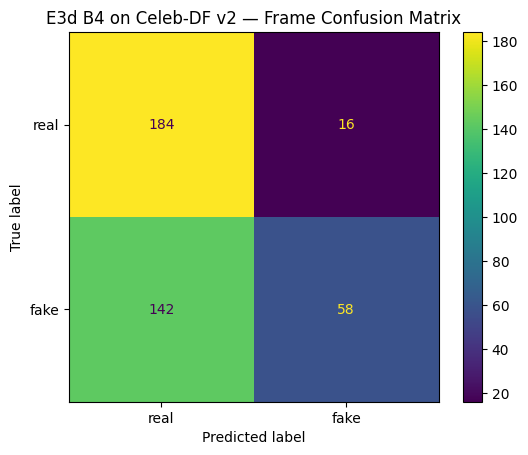

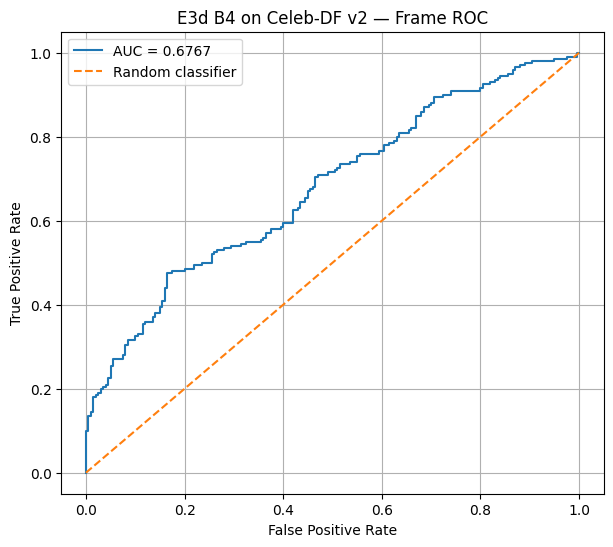

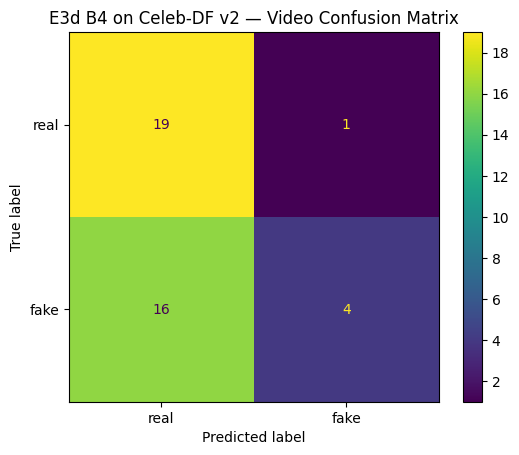

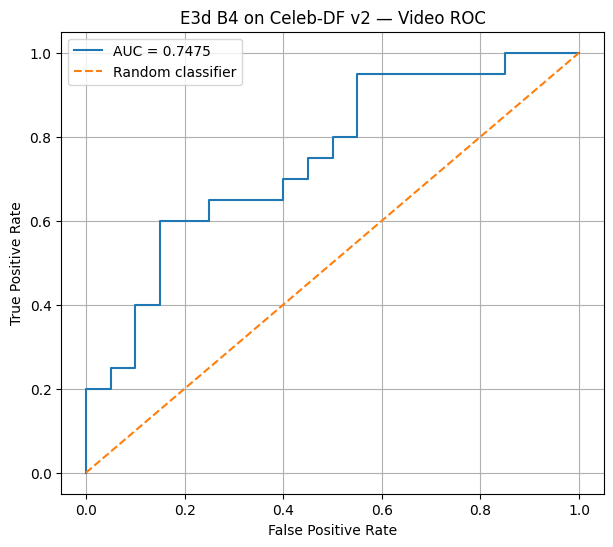

Results saved to: /content/drive/MyDrive/deepfake_project/results/cross_dataset/e3d_b4_celebdf_results.json
Frame predictions saved to: /content/drive/MyDrive/deepfake_project/results/cross_dataset/e3d_b4_celebdf_frame_predictions.csv
Video predictions saved to: /content/drive/MyDrive/deepfake_project/results/cross_dataset/e3d_b4_celebdf_video_predictions.csv


In [7]:
if RUN_EVALUATION:
    frame_records = []
    sample_offset = 0

    with torch.no_grad():
        for images, labels in test_loader:
            probabilities = torch.softmax(
                model(images.to(DEVICE)), dim=1
            )[:, FAKE_INDEX].cpu().numpy()

            batch_size_actual = labels.size(0)
            batch_samples = ordered_samples[
                sample_offset:sample_offset + batch_size_actual
            ]
            sample_offset += batch_size_actual

            for index, fake_probability in enumerate(probabilities):
                sample = batch_samples[index]
                true_label = int(labels[index])
                predicted_label = int(
                    fake_probability >= DECISION_THRESHOLD
                )
                frame_records.append({
                    "image_path": sample["path"],
                    "filename": sample["filename"],
                    "video_id": sample["video_id"],
                    "class_name": sample["class_name"],
                    "true_fake_label": true_label,
                    "true_class": "fake" if true_label == FAKE_INDEX else "real",
                    "predicted_fake_label": predicted_label,
                    "predicted_class": (
                        "fake" if predicted_label == FAKE_INDEX else "real"
                    ),
                    "fake_probability": float(fake_probability),
                })

    if sample_offset != len(test_dataset):
        raise RuntimeError(
            f"Inference covered {sample_offset} frames, "
            f"expected {len(test_dataset)}."
        )

    frame_df = pd.DataFrame(frame_records)
    if len(frame_df) != 400:
        raise RuntimeError(f"Expected 400 frame results, found {len(frame_df)}")

    video_df = (
        frame_df.groupby(["class_name", "video_id"], as_index=False)
        .agg(
            true_fake_label=("true_fake_label", "first"),
            mean_fake_probability=("fake_probability", "mean"),
            number_of_frames=("filename", "count"),
        )
    )
    video_df["predicted_fake_label"] = (
        video_df["mean_fake_probability"] >= DECISION_THRESHOLD
    ).astype(int)
    video_df["true_class"] = video_df["true_fake_label"].map(
        {REAL_INDEX: "real", FAKE_INDEX: "fake"}
    )
    video_df["predicted_class"] = video_df["predicted_fake_label"].map(
        {REAL_INDEX: "real", FAKE_INDEX: "fake"}
    )
    if len(video_df) != 40 or not video_df["number_of_frames"].eq(10).all():
        raise RuntimeError("Video aggregation did not preserve 40×10 pilot structure.")

    frame_metrics = metric_bundle(
        frame_df["true_fake_label"],
        frame_df["predicted_fake_label"],
        frame_df["fake_probability"],
    )
    video_metrics = metric_bundle(
        video_df["true_fake_label"],
        video_df["predicted_fake_label"],
        video_df["mean_fake_probability"],
    )

    frame_report = classification_report(
        frame_df["true_fake_label"],
        frame_df["predicted_fake_label"],
        labels=[REAL_INDEX, FAKE_INDEX],
        target_names=["real", "fake"],
        digits=4,
        zero_division=0,
    )
    video_report = classification_report(
        video_df["true_fake_label"],
        video_df["predicted_fake_label"],
        labels=[REAL_INDEX, FAKE_INDEX],
        target_names=["real", "fake"],
        digits=4,
        zero_division=0,
    )

    for title, count, metrics, report in (
        ("FRAME-LEVEL", len(frame_df), frame_metrics, frame_report),
        ("VIDEO-LEVEL", len(video_df), video_metrics, video_report),
    ):
        print("=" * 65)
        print(f"E3d B4 — CELEB-DF {title} RESULTS")
        print("=" * 65)
        print("Items evaluated :", count)
        print(f"Accuracy         : {metrics['accuracy'] * 100:.2f}%")
        print(f"Macro precision  : {metrics['macro_precision'] * 100:.2f}%")
        print(f"Macro recall     : {metrics['macro_recall'] * 100:.2f}%")
        print(f"Macro F1-score   : {metrics['macro_f1'] * 100:.2f}%")
        print(f"Fake recall      : {metrics['fake_recall'] * 100:.2f}%")
        print(f"ROC-AUC          : {metrics['roc_auc']:.4f}")
        print(report)
        print("Confusion matrix [real, fake]:")
        print(np.asarray(metrics["confusion_matrix"]))

    frame_df.to_csv(FRAME_CSV_PATH, index=False)
    video_df.to_csv(VIDEO_CSV_PATH, index=False)
    save_plots(
        "frame", frame_df["true_fake_label"],
        frame_df["fake_probability"], frame_metrics,
        FRAME_CM_PATH, FRAME_ROC_PATH,
    )
    save_plots(
        "video", video_df["true_fake_label"],
        video_df["mean_fake_probability"], video_metrics,
        VIDEO_CM_PATH, VIDEO_ROC_PATH,
    )

    result = {
        "experiment": "E3d",
        "model": "EfficientNet-B4 + official SBI",
        "training_dataset": "FaceForensics++",
        "external_test_dataset": "Celeb-DF v2 fixed pilot",
        "external_input": "native_380_retinaface_crop",
        "external_frame_identities_match_e3b": True,
        "synthetic_sbi_used_during_test": False,
        "preprocessing": (
            "Native 380x380 RGB; float32 scale [0,1]; "
            "no ImageNet mean/std normalization"
        ),
        "evaluation_type": (
            "cross-dataset; no retraining, adaptation or threshold tuning"
        ),
        "checkpoint": CHECKPOINT_PATH,
        "decision_threshold": DECISION_THRESHOLD,
        "model_fake_output_index": FAKE_INDEX,
        "video_aggregation": "mean fake probability across 10 frames",
        "frames_evaluated": len(frame_df),
        "videos_evaluated": len(video_df),
        "frame_level": frame_metrics,
        "video_level": video_metrics,
    }
    with open(RESULTS_PATH, "w", encoding="utf-8") as handle:
        json.dump(result, handle, indent=2)

    print("Results saved to:", RESULTS_PATH)
    print("Frame predictions saved to:", FRAME_CSV_PATH)
    print("Video predictions saved to:", VIDEO_CSV_PATH)
else:
    print("Evaluation skipped safely.")
    print("Set RUN_EVALUATION = True to evaluate the saved E3d checkpoint.")


## Methodological safeguards

- No Celeb-DF training, adaptation, SBI generation, checkpoint selection or threshold tuning occurs.
- The decision threshold remains fixed at 0.5.
- Native 380×380 input and [0,1] scaling without ImageNet normalisation match E3d training and internal evaluation.
- The complete EfficientNet-B4 checkpoint is loaded with `strict=True`.
- The B4 crops must exactly match the original E3b pilot filenames: 200 real + 200 fake frames from 40 videos.
- Frame-level results and mean-probability video-level results are saved separately.
- The result is a balanced 40-video pilot, not a full Celeb-DF benchmark.
- Interpret E3d against E3b. A better synthetic validation score alone does not demonstrate stronger generalisation.
